# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

def adjusted_r2_score(y_test, y_pred, n, p):
    score = r2_score(y_test, y_pred)
    return 1 - (1 - score) * (n - 1) / (n - p - 1)

## Data Loading

In [2]:
df_technical = pd.read_csv("C:/Users/Judit/Desktop/hw/25_26/Project/data/all/prices-split-adjusted.csv")
df_fundamental = pd.read_csv("C:/Users/Judit/Desktop/hw/25_26/Project/data/all/fundamentals.csv")
df_fundamental = df_fundamental.drop("Unnamed: 0", axis=1)
df_securities = pd.read_csv("C:/Users/Judit/Desktop/hw/25_26/Project/data/all/securities.csv")

In [3]:
display(df_technical)
display(df_technical.info())
df_technical.describe()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0
...,...,...,...,...,...,...,...
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0
851261,2016-12-30,ZTS,53.639999,53.529999,53.270000,53.740002,1701200.0
851262,2016-12-30,AIV,44.730000,45.450001,44.410000,45.590000,1380900.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB


None

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,75.120003,75.139999,74.400002,75.849998,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [4]:
display(df_fundamental)
display(df_fundamental.info())
df_fundamental.describe()

,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,1.330000e+09,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,2.175000e+09,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,1.768000e+09,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,1.085000e+09,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,5.981110e+08,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,ZION,2015-12-31,0.000000e+00,0.0,-2.530000e+06,4.0,-1.573610e+08,0.000000e+00,NaN,1.576313e+10,...,0.000000e+00,0.000000e+00,7.507519e+09,5.216201e+10,5.966952e+10,2.210591e+09,0.0,2015.0,1.20,2.578925e+08
1777,ZTS,2013-12-31,1.381000e+09,-99000000.0,9.000000e+06,54.0,-1.840000e+08,8.780000e+08,43.0,6.100000e+08,...,3.357000e+09,1.415000e+09,9.400000e+08,5.618000e+09,6.558000e+09,4.561000e+09,0.0,2013.0,1.01,4.990099e+08
1778,ZTS,2014-12-31,1.071000e+09,69000000.0,-7.000000e+06,44.0,-1.800000e+08,9.580000e+08,81.0,8.820000e+08,...,3.465000e+09,1.086000e+09,1.311000e+09,5.277000e+09,6.588000e+09,4.785000e+09,0.0,2014.0,1.16,5.025862e+08
1779,ZTS,2015-12-31,1.313000e+09,-58000000.0,-8.100000e+07,32.0,-2.240000e+08,1.012000e+09,65.0,1.154000e+09,...,3.830000e+09,1.781000e+09,1.068000e+09,6.845000e+09,7.913000e+09,4.765000e+09,-203000000.0,2015.0,0.68,4.985294e+08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 78 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Ticker Symbol                                        1781 non-null   object 
 1   Period Ending                                        1781 non-null   object 
 2   Accounts Payable                                     1781 non-null   float64
 3   Accounts Receivable                                  1781 non-null   float64
 4   Add'l income/expense items                           1781 non-null   float64
 5   After Tax ROE                                        1781 non-null   float64
 6   Capital Expenditures                                 1781 non-null   float64
 7   Capital Surplus                                      1781 non-null   float64
 8   Cash Ratio                                           1482 non-null  

None

,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,Common Stocks,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
count,1.781000e+03,1.781000e+03,1.781000e+03,1781.000000,1.781000e+03,1.781000e+03,1482.000000,1.781000e+03,1.781000e+03,1.781000e+03,...,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1608.000000,1562.000000,1.562000e+03
mean,4.673418e+09,-6.353484e+07,6.908940e+07,43.601348,-1.251925e+09,5.351784e+09,74.457490,8.521399e+09,-6.787749e+07,1.608543e+09,...,6.726349e+09,4.699919e+09,1.188846e+10,4.380420e+10,5.569266e+10,2.029154e+10,-3.951522e+09,2013.305348,3.353707,6.024244e+08
std,1.406047e+10,7.562794e+08,6.848143e+08,233.924028,2.979963e+09,1.133977e+10,102.298374,5.432105e+10,3.903369e+08,9.177636e+09,...,1.344800e+10,9.538832e+09,2.584429e+10,1.817039e+11,2.033612e+11,4.095355e+10,1.407047e+10,19.953135,4.695896,1.142585e+09
min,0.000000e+00,-6.452000e+09,-6.768000e+09,0.000000,-3.798500e+10,-7.215000e+08,0.000000,2.100000e+04,-5.562000e+09,0.000000e+00,...,0.000000e+00,0.000000e+00,-1.324400e+10,2.577000e+06,2.705000e+06,1.514000e+06,-2.297340e+11,1215.000000,-61.200000,-1.513945e+09
25%,5.160000e+08,-1.040000e+08,-2.638000e+06,10.000000,-1.151200e+09,4.791000e+08,17.000000,3.088000e+08,-5.400000e+07,1.628000e+06,...,1.044178e+09,5.640760e+08,2.201492e+09,3.843300e+09,6.552689e+09,3.714000e+09,-3.040895e+09,2013.000000,1.590000,1.493318e+08
50%,1.334000e+09,-1.830000e+07,2.000000e+06,16.000000,-3.580000e+08,1.997080e+09,41.000000,8.625900e+08,0.000000e+00,7.725000e+06,...,2.747200e+09,1.701500e+09,4.983000e+09,9.141000e+09,1.517000e+10,8.023200e+09,-3.068350e+08,2014.000000,2.810000,2.929409e+08
75%,3.246000e+09,7.816000e+06,3.359200e+07,26.000000,-1.291000e+08,5.735000e+09,90.000000,2.310000e+09,0.000000e+00,2.970000e+08,...,6.162000e+09,4.381000e+09,1.080900e+10,2.389700e+10,3.599710e+10,1.748600e+10,0.000000e+00,2015.000000,4.590000,5.492163e+08
max,2.069390e+11,2.266400e+10,1.416200e+10,5789.000000,5.000000e+06,1.082880e+11,1041.000000,7.281110e+11,3.755000e+09,1.581420e+11,...,1.396600e+11,9.028100e+10,2.562050e+11,2.340547e+12,2.572274e+12,4.856510e+11,0.000000e+00,2016.000000,50.090000,1.610769e+10


In [5]:
display(df_securities)
display(df_securities.info())
df_securities.describe()

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",2015-08-31,718877
...,...,...,...,...,...,...,...,...
500,YHOO,Yahoo Inc.,reports,Information Technology,Internet Software & Services,"Sunnyvale, California",NaN,1011006
501,YUM,Yum! Brands Inc,reports,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061
502,ZBH,Zimmer Biomet Holdings,reports,Health Care,Health Care Equipment,"Warsaw, Indiana",NaN,1136869
503,ZION,Zions Bancorp,reports,Financials,Regional Banks,"Salt Lake City, Utah",NaN,109380


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Ticker symbol            505 non-null    object
 1   Security                 505 non-null    object
 2   SEC filings              505 non-null    object
 3   GICS Sector              505 non-null    object
 4   GICS Sub Industry        505 non-null    object
 5   Address of Headquarters  505 non-null    object
 6   Date first added         307 non-null    object
 7   CIK                      505 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 31.7+ KB


None

,CIK
count,5.050000e+02
mean,7.074490e+05
std,5.144375e+05
min,1.800000e+03
25%,8.631200e+04
50%,8.310010e+05
75%,1.075531e+06
max,1.659166e+06


## Stock Filtering

In [6]:
df_securities["GICS Sector"].value_counts()

Consumer Discretionary         85
Industrials                    69
Information Technology         68
Financials                     64
Health Care                    59
Consumer Staples               37
Energy                         36
Real Estate                    29
Utilities                      28
Materials                      25
Telecommunications Services     5
Name: GICS Sector, dtype: int64

In [7]:
all_tech_symbol = list(df_securities[df_securities["GICS Sector"]=="Information Technology"]["Ticker symbol"])

df_technical_tech = df_technical[df_technical["symbol"].isin(all_tech_symbol)]
symbol_close = df_technical_tech.groupby("symbol")["volume"].mean().reset_index()
symbol_close = symbol_close.sort_values(by="volume", ascending=False).reset_index(drop=True)[:3]
top_tech_symbol = list(symbol_close["symbol"])

display(df_securities[df_securities["Ticker symbol"].isin(top_tech_symbol)].reset_index(drop=True))

df_technical = df_technical[df_technical["symbol"].isin(top_tech_symbol)].reset_index(drop=True)
df_fundamental = df_fundamental[df_fundamental["Ticker Symbol"].isin(top_tech_symbol)].reset_index(drop=True)

display(df_technical)
display(df_fundamental)

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,AAPL,Apple Inc.,reports,Information Technology,Computer Hardware,"Cupertino, California",1982-11-30,320193
1,INTC,Intel Corp.,reports,Information Technology,Semiconductors,"Santa Clara, California",1976-12-31,50863
2,MSFT,Microsoft Corp.,reports,Information Technology,Systems Software,"Redmond, Washington",1994-06-01,789019


,date,symbol,open,close,low,high,volume
0,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0
1,2010-01-04,INTC,20.790001,20.879999,20.730000,21.030001,47800900.0
2,2010-01-04,MSFT,30.620001,30.950001,30.590000,31.100000,38409100.0
3,2010-01-05,AAPL,30.657143,30.625713,30.464285,30.798571,150476200.0
4,2010-01-05,INTC,20.940001,20.870001,20.600000,20.990000,52357700.0
...,...,...,...,...,...,...,...
5281,2016-12-29,INTC,36.509998,36.660000,36.430000,36.720001,8447300.0
5282,2016-12-29,MSFT,62.860001,62.900002,62.730000,63.200001,10250600.0
5283,2016-12-30,AAPL,116.650002,115.820000,115.430000,117.199997,30586300.0
5284,2016-12-30,INTC,36.790001,36.270000,36.200001,36.799999,17468000.0


,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,AAPL,2013-09-28,3.622300e+10,-1.949000e+09,1.156000e+09,30.0,-8.165000e+09,0.0,93.0,1.425900e+10,...,7.328600e+10,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,2013.0,40.03,9.252311e+08
1,AAPL,2014-09-27,4.864900e+10,-6.452000e+09,9.800000e+08,35.0,-9.571000e+09,0.0,40.0,1.384400e+10,...,6.853100e+10,6.344800e+10,1.115470e+11,1.202920e+11,2.318390e+11,1.827950e+11,0.0,2014.0,6.49,6.087827e+09
2,AAPL,2015-09-26,6.067100e+10,-3.124000e+09,1.285000e+09,45.0,-1.124700e+10,0.0,52.0,2.112000e+10,...,8.937800e+10,8.061000e+10,1.193550e+11,1.709900e+11,2.903450e+11,2.337150e+11,0.0,2015.0,9.28,5.753664e+09
3,AAPL,2016-09-24,5.932100e+10,1.044000e+09,1.348000e+09,36.0,-1.273400e+10,0.0,85.0,2.048400e+10,...,1.068690e+11,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,2016.0,8.35,5.471497e+09
4,INTC,2013-12-28,1.119100e+10,2.710000e+08,0.000000e+00,17.0,-1.071100e+10,0.0,148.0,5.674000e+09,...,3.208400e+10,1.356800e+10,5.825600e+10,3.410200e+10,9.235800e+10,5.270800e+10,0.0,2013.0,1.94,4.958763e+09
5,INTC,2014-12-27,1.221000e+10,-8.610000e+08,0.000000e+00,21.0,-1.010500e+10,0.0,88.0,2.561000e+09,...,2.773000e+10,1.601100e+10,5.586500e+10,3.603500e+10,9.190000e+10,5.587000e+10,0.0,2014.0,2.39,4.897071e+09
6,INTC,2015-12-26,1.076800e+10,-3.550000e+08,0.000000e+00,19.0,-7.326000e+09,0.0,162.0,1.530800e+10,...,3.832000e+10,1.564600e+10,6.108500e+10,4.037400e+10,1.014590e+11,5.535500e+10,0.0,2015.0,2.41,4.738589e+09
7,INTC,2016-12-31,1.203000e+10,6.500000e+07,0.000000e+00,16.0,-9.625000e+09,0.0,84.0,5.560000e+09,...,3.550800e+10,2.030200e+10,6.622600e+10,4.710100e+10,1.133270e+11,5.938700e+10,0.0,NaN,NaN,NaN
8,MSFT,2013-06-30,1.018200e+10,-1.807000e+09,2.880000e+08,28.0,-4.257000e+09,0.0,206.0,3.804000e+09,...,1.014660e+11,3.741700e+10,7.894400e+10,6.348700e+10,1.424310e+11,7.784900e+10,0.0,2013.0,2.61,8.376628e+09
9,MSFT,2014-06-30,1.356900e+10,-1.120000e+09,6.100000e+07,25.0,-5.485000e+09,0.0,188.0,8.669000e+09,...,1.142460e+11,4.562500e+10,8.978400e+10,8.260000e+10,1.723840e+11,8.683300e+10,0.0,2014.0,2.66,8.298496e+09


# Feature Engineering


## Technical Data

In [8]:
# Datetime Features
print("Before Adding Datetime Features:", df_technical.shape)

col = "date"
prefix = col + "_"
df_technical[col] = pd.to_datetime(df_technical[col])
df_technical[prefix + 'year'] = df_technical[col].dt.year
df_technical[prefix + 'month'] = df_technical[col].dt.month
df_technical[prefix + 'day'] = df_technical[col].dt.day
df_technical[prefix + 'weekofyear'] = df_technical[col].dt.weekofyear
df_technical[prefix + 'dayofweek'] = df_technical[col].dt.dayofweek
df_technical[prefix + 'quarter'] = df_technical[col].dt.quarter
df_technical[prefix + 'is_month_start'] = df_technical[col].dt.is_month_start.astype(int)
df_technical[prefix + 'is_month_end'] = df_technical[col].dt.is_month_end.astype(int)

print(" After Adding Datetime Features:", df_technical.shape)

df_technical

Before Adding Datetime Features: (5286, 7)
 After Adding Datetime Features: (5286, 15)


,date,symbol,open,close,low,high,volume,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,date_is_month_end
0,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0,2010,1,4,1,0,1,0,0
1,2010-01-04,INTC,20.790001,20.879999,20.730000,21.030001,47800900.0,2010,1,4,1,0,1,0,0
2,2010-01-04,MSFT,30.620001,30.950001,30.590000,31.100000,38409100.0,2010,1,4,1,0,1,0,0
3,2010-01-05,AAPL,30.657143,30.625713,30.464285,30.798571,150476200.0,2010,1,5,1,1,1,0,0
4,2010-01-05,INTC,20.940001,20.870001,20.600000,20.990000,52357700.0,2010,1,5,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5281,2016-12-29,INTC,36.509998,36.660000,36.430000,36.720001,8447300.0,2016,12,29,52,3,4,0,0
5282,2016-12-29,MSFT,62.860001,62.900002,62.730000,63.200001,10250600.0,2016,12,29,52,3,4,0,0
5283,2016-12-30,AAPL,116.650002,115.820000,115.430000,117.199997,30586300.0,2016,12,30,52,4,4,0,0
5284,2016-12-30,INTC,36.790001,36.270000,36.200001,36.799999,17468000.0,2016,12,30,52,4,4,0,0


In [9]:
# Lag Features
print("Before Adding Lag Features:", df_technical.shape)

ohlcv = ["open", "high", "low", "close", "volume"]
for col in ohlcv:
    lags = np.arange(65, 101, 1)
    for lag in lags:
        df_technical["{}_lag_{}".format(col, lag)] = df_technical.groupby("symbol")[col].transform(lambda x: x.shift(lag))

print(" After Adding Lag Features:", df_technical.shape)

df_technical

Before Adding Lag Features: (5286, 15)
 After Adding Lag Features: (5286, 195)


,date,symbol,open,close,low,high,volume,date_year,date_month,date_day,...,volume_lag_91,volume_lag_92,volume_lag_93,volume_lag_94,volume_lag_95,volume_lag_96,volume_lag_97,volume_lag_98,volume_lag_99,volume_lag_100
0,2010-01-04,AAPL,30.490000,30.572857,30.340000,30.642857,123432400.0,2010,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,INTC,20.790001,20.879999,20.730000,21.030001,47800900.0,2010,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,MSFT,30.620001,30.950001,30.590000,31.100000,38409100.0,2010,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-05,AAPL,30.657143,30.625713,30.464285,30.798571,150476200.0,2010,1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-05,INTC,20.940001,20.870001,20.600000,20.990000,52357700.0,2010,1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5281,2016-12-29,INTC,36.509998,36.660000,36.430000,36.720001,8447300.0,2016,12,29,...,16417600.0,16085200.0,18221600.0,16320900.0,18931100.0,15708300.0,16364100.0,19579000.0,12578900.0,19497300.0
5282,2016-12-29,MSFT,62.860001,62.900002,62.730000,63.200001,10250600.0,2016,12,29,...,17271000.0,14214300.0,18856400.0,20523500.0,19283900.0,21655200.0,18162300.0,15756900.0,16920700.0,19473500.0
5283,2016-12-30,AAPL,116.650002,115.820000,115.430000,117.199997,30586300.0,2016,12,30,...,25820200.0,25368100.0,21984700.0,25356000.0,33794400.0,25868200.0,18660400.0,27484500.0,24008500.0,26315200.0
5284,2016-12-30,INTC,36.790001,36.270000,36.200001,36.799999,17468000.0,2016,12,30,...,14941400.0,16417600.0,16085200.0,18221600.0,16320900.0,18931100.0,15708300.0,16364100.0,19579000.0,12578900.0


In [10]:
# Drop Features
print("Before Drop Features:", df_technical.shape)

drop_features = ["open", "high", "low", "volume"]
df_technical = df_technical.drop(drop_features, axis=1)

print(" After Drop Features:", df_technical.shape)

df_technical

Before Drop Features: (5286, 195)
 After Drop Features: (5286, 191)


,date,symbol,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,...,volume_lag_91,volume_lag_92,volume_lag_93,volume_lag_94,volume_lag_95,volume_lag_96,volume_lag_97,volume_lag_98,volume_lag_99,volume_lag_100
0,2010-01-04,AAPL,30.572857,2010,1,4,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,INTC,20.879999,2010,1,4,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,MSFT,30.950001,2010,1,4,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-05,AAPL,30.625713,2010,1,5,1,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-05,INTC,20.870001,2010,1,5,1,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5281,2016-12-29,INTC,36.660000,2016,12,29,52,3,4,0,...,16417600.0,16085200.0,18221600.0,16320900.0,18931100.0,15708300.0,16364100.0,19579000.0,12578900.0,19497300.0
5282,2016-12-29,MSFT,62.900002,2016,12,29,52,3,4,0,...,17271000.0,14214300.0,18856400.0,20523500.0,19283900.0,21655200.0,18162300.0,15756900.0,16920700.0,19473500.0
5283,2016-12-30,AAPL,115.820000,2016,12,30,52,4,4,0,...,25820200.0,25368100.0,21984700.0,25356000.0,33794400.0,25868200.0,18660400.0,27484500.0,24008500.0,26315200.0
5284,2016-12-30,INTC,36.270000,2016,12,30,52,4,4,0,...,14941400.0,16417600.0,16085200.0,18221600.0,16320900.0,18931100.0,15708300.0,16364100.0,19579000.0,12578900.0


## Fundamental Data

In [11]:
# Datetime Features
print("Before Adding Datetime Features:", df_fundamental.shape)

df_fundamental["Period Ending"] = pd.to_datetime(df_fundamental["Period Ending"])
df_fundamental["First_Date_Tech"] = df_fundamental["Period Ending"] + pd.Timedelta(days=1)
df_fundamental['Last_Date_Tech'] = df_fundamental.groupby("Ticker Symbol")["Period Ending"].shift(-1)
df_fundamental['Last_Date_Tech'] = df_fundamental['Last_Date_Tech'].fillna(df_fundamental['Period Ending'] + pd.offsets.DateOffset(years=1))

print(" After Adding Datetime Features:", df_fundamental.shape)

df_fundamental

Before Adding Datetime Features: (12, 78)
 After Adding Datetime Features: (12, 80)


,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,...,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,First_Date_Tech,Last_Date_Tech
0,AAPL,2013-09-28,3.622300e+10,-1.949000e+09,1.156000e+09,30.0,-8.165000e+09,0.0,93.0,1.425900e+10,...,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,2013.0,40.03,9.252311e+08,2013-09-29,2014-09-27
1,AAPL,2014-09-27,4.864900e+10,-6.452000e+09,9.800000e+08,35.0,-9.571000e+09,0.0,40.0,1.384400e+10,...,1.115470e+11,1.202920e+11,2.318390e+11,1.827950e+11,0.0,2014.0,6.49,6.087827e+09,2014-09-28,2015-09-26
2,AAPL,2015-09-26,6.067100e+10,-3.124000e+09,1.285000e+09,45.0,-1.124700e+10,0.0,52.0,2.112000e+10,...,1.193550e+11,1.709900e+11,2.903450e+11,2.337150e+11,0.0,2015.0,9.28,5.753664e+09,2015-09-27,2016-09-24
3,AAPL,2016-09-24,5.932100e+10,1.044000e+09,1.348000e+09,36.0,-1.273400e+10,0.0,85.0,2.048400e+10,...,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,2016.0,8.35,5.471497e+09,2016-09-25,2017-09-24
4,INTC,2013-12-28,1.119100e+10,2.710000e+08,0.000000e+00,17.0,-1.071100e+10,0.0,148.0,5.674000e+09,...,5.825600e+10,3.410200e+10,9.235800e+10,5.270800e+10,0.0,2013.0,1.94,4.958763e+09,2013-12-29,2014-12-27
5,INTC,2014-12-27,1.221000e+10,-8.610000e+08,0.000000e+00,21.0,-1.010500e+10,0.0,88.0,2.561000e+09,...,5.586500e+10,3.603500e+10,9.190000e+10,5.587000e+10,0.0,2014.0,2.39,4.897071e+09,2014-12-28,2015-12-26
6,INTC,2015-12-26,1.076800e+10,-3.550000e+08,0.000000e+00,19.0,-7.326000e+09,0.0,162.0,1.530800e+10,...,6.108500e+10,4.037400e+10,1.014590e+11,5.535500e+10,0.0,2015.0,2.41,4.738589e+09,2015-12-27,2016-12-31
7,INTC,2016-12-31,1.203000e+10,6.500000e+07,0.000000e+00,16.0,-9.625000e+09,0.0,84.0,5.560000e+09,...,6.622600e+10,4.710100e+10,1.133270e+11,5.938700e+10,0.0,NaN,NaN,NaN,2017-01-01,2017-12-31
8,MSFT,2013-06-30,1.018200e+10,-1.807000e+09,2.880000e+08,28.0,-4.257000e+09,0.0,206.0,3.804000e+09,...,7.894400e+10,6.348700e+10,1.424310e+11,7.784900e+10,0.0,2013.0,2.61,8.376628e+09,2013-07-01,2014-06-30
9,MSFT,2014-06-30,1.356900e+10,-1.120000e+09,6.100000e+07,25.0,-5.485000e+09,0.0,188.0,8.669000e+09,...,8.978400e+10,8.260000e+10,1.723840e+11,8.683300e+10,0.0,2014.0,2.66,8.298496e+09,2014-07-01,2015-06-30


In [12]:
# Drop Features
print("Before Drop Features:", df_fundamental.shape)

# drop_features = ["Period Ending", "Cash Ratio", "Current Ratio", "Quick Ratio", "For Year", "Earnings Per Share", "Estimated Shares Outstanding"]
drop_features = ["Period Ending", "For Year"]
df_fundamental = df_fundamental.drop(drop_features, axis=1)

print(" After Drop Features:", df_fundamental.shape)

df_fundamental

Before Drop Features: (12, 80)
 After Drop Features: (12, 78)


,Ticker Symbol,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,Earnings Per Share,Estimated Shares Outstanding,First_Date_Tech,Last_Date_Tech
0,AAPL,3.622300e+10,-1.949000e+09,1.156000e+09,30.0,-8.165000e+09,0.0,93.0,1.425900e+10,-973000000.0,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,2013-09-29,2014-09-27
1,AAPL,4.864900e+10,-6.452000e+09,9.800000e+08,35.0,-9.571000e+09,0.0,40.0,1.384400e+10,-76000000.0,...,6.344800e+10,1.115470e+11,1.202920e+11,2.318390e+11,1.827950e+11,0.0,6.49,6.087827e+09,2014-09-28,2015-09-26
2,AAPL,6.067100e+10,-3.124000e+09,1.285000e+09,45.0,-1.124700e+10,0.0,52.0,2.112000e+10,-238000000.0,...,8.061000e+10,1.193550e+11,1.709900e+11,2.903450e+11,2.337150e+11,0.0,9.28,5.753664e+09,2015-09-27,2016-09-24
3,AAPL,5.932100e+10,1.044000e+09,1.348000e+09,36.0,-1.273400e+10,0.0,85.0,2.048400e+10,217000000.0,...,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,8.35,5.471497e+09,2016-09-25,2017-09-24
4,INTC,1.119100e+10,2.710000e+08,0.000000e+00,17.0,-1.071100e+10,0.0,148.0,5.674000e+09,563000000.0,...,1.356800e+10,5.825600e+10,3.410200e+10,9.235800e+10,5.270800e+10,0.0,1.94,4.958763e+09,2013-12-29,2014-12-27
5,INTC,1.221000e+10,-8.610000e+08,0.000000e+00,21.0,-1.010500e+10,0.0,88.0,2.561000e+09,-98000000.0,...,1.601100e+10,5.586500e+10,3.603500e+10,9.190000e+10,5.587000e+10,0.0,2.39,4.897071e+09,2014-12-28,2015-12-26
6,INTC,1.076800e+10,-3.550000e+08,0.000000e+00,19.0,-7.326000e+09,0.0,162.0,1.530800e+10,-764000000.0,...,1.564600e+10,6.108500e+10,4.037400e+10,1.014590e+11,5.535500e+10,0.0,2.41,4.738589e+09,2015-12-27,2016-12-31
7,INTC,1.203000e+10,6.500000e+07,0.000000e+00,16.0,-9.625000e+09,0.0,84.0,5.560000e+09,119000000.0,...,2.030200e+10,6.622600e+10,4.710100e+10,1.133270e+11,5.938700e+10,0.0,NaN,NaN,2017-01-01,2017-12-31
8,MSFT,1.018200e+10,-1.807000e+09,2.880000e+08,28.0,-4.257000e+09,0.0,206.0,3.804000e+09,-802000000.0,...,3.741700e+10,7.894400e+10,6.348700e+10,1.424310e+11,7.784900e+10,0.0,2.61,8.376628e+09,2013-07-01,2014-06-30
9,MSFT,1.356900e+10,-1.120000e+09,6.100000e+07,25.0,-5.485000e+09,0.0,188.0,8.669000e+09,-161000000.0,...,4.562500e+10,8.978400e+10,8.260000e+10,1.723840e+11,8.683300e+10,0.0,2.66,8.298496e+09,2014-07-01,2015-06-30


## Merging All Data

In [13]:
# Filtering Date and Symbol in Technical Data
df_technical = df_technical[(df_technical["date"]>="2014-01-01")&(df_technical["date"]<="2016-12-31")].reset_index(drop=True)
# df_technical = df_technical[(df_technical["date"]>="2010-01-01")&(df_technical["date"]<="2016-12-31")].reset_index(drop=True)
df_technical

,date,symbol,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,...,volume_lag_91,volume_lag_92,volume_lag_93,volume_lag_94,volume_lag_95,volume_lag_96,volume_lag_97,volume_lag_98,volume_lag_99,volume_lag_100
0,2014-01-02,AAPL,79.018570,2014,1,2,1,3,1,0,...,61051900.0,83969900.0,89672100.0,127629600.0,90576500.0,122573500.0,189093100.0,220485300.0,91108500.0,66716300.0
1,2014-01-02,INTC,25.790001,2014,1,2,1,3,1,0,...,17380600.0,32403300.0,32084300.0,43412200.0,30079000.0,40451200.0,23202500.0,26099200.0,23520400.0,25145400.0
2,2014-01-02,MSFT,37.160000,2014,1,2,1,3,1,0,...,31169900.0,37409100.0,22979600.0,27902500.0,32866300.0,33338000.0,48519600.0,39464100.0,25493700.0,26800700.0
3,2014-01-03,AAPL,77.282860,2014,1,3,1,4,1,0,...,55682900.0,61051900.0,83969900.0,89672100.0,127629600.0,90576500.0,122573500.0,189093100.0,220485300.0,91108500.0
4,2014-01-03,INTC,25.780001,2014,1,3,1,4,1,0,...,23088700.0,17380600.0,32403300.0,32084300.0,43412200.0,30079000.0,40451200.0,23202500.0,26099200.0,23520400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,2016-12-29,INTC,36.660000,2016,12,29,52,3,4,0,...,16417600.0,16085200.0,18221600.0,16320900.0,18931100.0,15708300.0,16364100.0,19579000.0,12578900.0,19497300.0
2264,2016-12-29,MSFT,62.900002,2016,12,29,52,3,4,0,...,17271000.0,14214300.0,18856400.0,20523500.0,19283900.0,21655200.0,18162300.0,15756900.0,16920700.0,19473500.0
2265,2016-12-30,AAPL,115.820000,2016,12,30,52,4,4,0,...,25820200.0,25368100.0,21984700.0,25356000.0,33794400.0,25868200.0,18660400.0,27484500.0,24008500.0,26315200.0
2266,2016-12-30,INTC,36.270000,2016,12,30,52,4,4,0,...,14941400.0,16417600.0,16085200.0,18221600.0,16320900.0,18931100.0,15708300.0,16364100.0,19579000.0,12578900.0


In [14]:
# Merging Technical and Fundamental Data
df_tech_fund = df_technical.merge(df_fundamental, left_on="symbol", right_on="Ticker Symbol")
df_tech_fund = df_tech_fund[(df_tech_fund["date"]>=df_tech_fund["First_Date_Tech"]) & (df_tech_fund["date"]<=df_tech_fund["Last_Date_Tech"])].reset_index(drop=True)

# df_tech_fund = df_technical.copy()
df_tech_fund

,date,symbol,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,Earnings Per Share,Estimated Shares Outstanding,First_Date_Tech,Last_Date_Tech
0,2014-01-02,AAPL,79.018570,2014,1,2,1,3,1,0,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,2013-09-29,2014-09-27
1,2014-01-03,AAPL,77.282860,2014,1,3,1,4,1,0,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,2013-09-29,2014-09-27
2,2014-01-06,AAPL,77.704285,2014,1,6,2,0,1,0,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,2013-09-29,2014-09-27
3,2014-01-07,AAPL,77.148575,2014,1,7,2,1,1,0,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,2013-09-29,2014-09-27
4,2014-01-08,AAPL,77.637146,2014,1,8,2,2,1,0,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,2013-09-29,2014-09-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,2016-12-23,MSFT,63.240002,2016,12,23,51,4,4,0,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,2016-07-01,2017-06-30
2264,2016-12-27,MSFT,63.279999,2016,12,27,52,1,4,0,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,2016-07-01,2017-06-30
2265,2016-12-28,MSFT,62.990002,2016,12,28,52,2,4,0,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,2016-07-01,2017-06-30
2266,2016-12-29,MSFT,62.900002,2016,12,29,52,3,4,0,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,2016-07-01,2017-06-30


In [15]:
# Drop Features
print("Before Drop Features:", df_tech_fund.shape)

drop_features = ["Ticker Symbol", "First_Date_Tech", "Last_Date_Tech"]
df_tech_fund = df_tech_fund.drop(drop_features, axis=1)

print(" After Drop Features:", df_tech_fund.shape)

df_tech_fund.head()

Before Drop Features: (2268, 269)
 After Drop Features: (2268, 266)


,date,symbol,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,...,Total Assets,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,Earnings Per Share,Estimated Shares Outstanding
0,2014-01-02,AAPL,79.018570,2014,1,2,1,3,1,0,...,2.070000e+11,7.328600e+10,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08
1,2014-01-03,AAPL,77.282860,2014,1,3,1,4,1,0,...,2.070000e+11,7.328600e+10,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08
2,2014-01-06,AAPL,77.704285,2014,1,6,2,0,1,0,...,2.070000e+11,7.328600e+10,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08
3,2014-01-07,AAPL,77.148575,2014,1,7,2,1,1,0,...,2.070000e+11,7.328600e+10,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08
4,2014-01-08,AAPL,77.637146,2014,1,8,2,2,1,0,...,2.070000e+11,7.328600e+10,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08


## Data Splitting

In [16]:
# Data Splitting (Train: 2014-Q3 2016, Test: Q4 2016)
df_train = df_tech_fund[df_tech_fund["date"] < "2016-10-01"].reset_index(drop=True)
df_test = df_tech_fund[df_tech_fund["date"] >= "2016-10-01"].reset_index(drop=True)

# Create Actual Predicted DataFrame
df_actual_predicted = pd.DataFrame({
    "date": df_train["date"],
    "symbol": df_train["symbol"],
    "actual": df_train["close"], 
})

df_actual_predicted_test = pd.DataFrame({
    "date": df_test["date"],
    "symbol": df_test["symbol"],
    "actual": df_test["close"], 
})

df_actual_predicted = df_actual_predicted.append(df_actual_predicted_test, ignore_index=True)

# Categorical Encoding
categorical_features = ["symbol"]

df_category = pd.get_dummies(data=df_train[categorical_features], drop_first=True)
df_train = pd.concat([df_train, df_category], axis=1)
df_train = df_train.drop(categorical_features, axis=1)

df_category = pd.get_dummies(data=df_test[categorical_features], drop_first=True)
df_test = pd.concat([df_test, df_category], axis=1)
df_test = df_test.drop(categorical_features, axis=1)

# Drop Date Features
df_train = df_train.drop("date", axis=1)
df_test = df_test.drop("date", axis=1)

# 

print("Train Dataset")
display(df_train)

print("Test Dataset")
display(df_test)

X_train = df_train.drop("close", axis=1)
y_train = df_train["close"]
X_test = df_test.drop("close", axis=1)
y_test = df_test["close"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print(" X_test:", X_test.shape)
print(" y_test:", y_test.shape)

Train Dataset


,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,date_is_month_end,open_lag_65,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,Earnings Per Share,Estimated Shares Outstanding,symbol_INTC,symbol_MSFT
0,79.018570,2014,1,2,1,3,1,0,0,68.178574,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,0,0
1,77.282860,2014,1,3,1,4,1,0,0,68.349998,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,0,0
2,77.704285,2014,1,6,2,0,1,0,0,69.375717,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,0,0
3,77.148575,2014,1,7,2,1,1,0,0,70.072861,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,0,0
4,77.637146,2014,1,8,2,2,1,0,0,69.122856,...,4.365800e+10,1.235490e+11,8.345100e+10,2.070000e+11,1.709100e+11,0.0,40.03,9.252311e+08,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2074,56.900002,2016,9,26,39,0,3,0,0,51.279999,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1
2075,57.950001,2016,9,27,39,1,3,0,0,49.810001,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1
2076,58.029999,2016,9,28,39,2,3,0,0,49.099998,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1
2077,57.400002,2016,9,29,39,3,3,0,0,48.919998,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1


Test Dataset


,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,date_is_month_end,open_lag_65,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,Earnings Per Share,Estimated Shares Outstanding,symbol_INTC,symbol_MSFT
0,112.519997,2016,10,3,40,0,4,0,0,94.440002,...,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,8.35,5.471497e+09,0,0
1,113.000000,2016,10,4,40,1,4,0,0,95.489998,...,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,8.35,5.471497e+09,0,0
2,113.050003,2016,10,5,40,2,4,0,0,95.389999,...,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,8.35,5.471497e+09,0,0
3,113.889999,2016,10,6,40,3,4,0,0,94.599998,...,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,8.35,5.471497e+09,0,0
4,114.059998,2016,10,7,40,4,4,0,0,95.699997,...,7.900600e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.156390e+11,0.0,8.35,5.471497e+09,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,63.240002,2016,12,23,51,4,4,0,0,57.919998,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1
185,63.279999,2016,12,27,52,1,4,0,0,57.869999,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1
186,62.990002,2016,12,28,52,2,4,0,0,57.080002,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1
187,62.900002,2016,12,29,52,3,4,0,0,56.930000,...,5.935700e+10,7.199700e+10,1.216970e+11,1.936940e+11,8.532000e+10,0.0,2.12,7.923585e+09,0,1


X_train: (2079, 265)
y_train: (2079,)
 X_test: (189, 265)
 y_test: (189,)


# Stock Forecasting

## ARIMA Modell

In [17]:
arima_df_train = df_train.copy()
arima_df_test = df_test.copy()
arima_df_train.describe()

,close,date_year,date_month,date_day,date_weekofyear,date_dayofweek,date_quarter,date_is_month_start,date_is_month_end,open_lag_65,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,Earnings Per Share,Estimated Shares Outstanding,symbol_INTC,symbol_MSFT
count,2079.000000,2079.000000,2079.000000,2079.000000,2079.000000,2079.000000,2079.000000,2079.000000,2079.000000,2079.000000,...,2.079000e+03,2.079000e+03,2.079000e+03,2.079000e+03,2.079000e+03,2079.0,2079.000000,2.079000e+03,2079.000000,2079.000000
mean,61.191954,2014.909091,6.154401,15.746032,25.044733,2.015873,2.382395,0.028860,0.033189,59.251269,...,4.212967e+10,8.618492e+10,8.431257e+10,1.704975e+11,1.134748e+11,0.0,6.974646,5.895862e+09,0.333333,0.333333
std,33.052353,0.792718,3.286265,8.750083,14.374625,1.396489,1.065017,0.167453,0.179173,32.795810,...,2.239097e+10,2.486501e+10,4.401299e+10,6.595568e+10,6.354988e+10,0.0,10.666381,2.097591e+09,0.471518,0.471518
min,23.520000,2014.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,22.510000,...,1.356800e+10,5.586500e+10,3.410200e+10,9.190000e+10,5.270800e+10,0.0,1.490000,9.252311e+08,0.000000,0.000000
25%,34.305000,2014.000000,3.000000,8.000000,13.000000,1.000000,1.000000,0.000000,0.000000,33.565000,...,1.601100e+10,6.108500e+10,4.037400e+10,1.014590e+11,5.587000e+10,0.0,2.120000,4.897071e+09,0.000000,0.000000
50%,46.660000,2015.000000,6.000000,16.000000,25.000000,2.000000,2.000000,0.000000,0.000000,45.400002,...,4.562500e+10,8.008300e+10,8.260000e+10,1.723840e+11,8.683300e+10,0.0,2.610000,5.753664e+09,0.000000,0.000000
75%,95.340000,2016.000000,9.000000,23.000000,37.000000,3.000000,3.000000,0.000000,0.000000,90.785000,...,5.935700e+10,1.115470e+11,1.202920e+11,2.070000e+11,1.709100e+11,0.0,6.490000,8.183221e+09,1.000000,1.000000
max,133.000000,2016.000000,12.000000,31.000000,53.000000,4.000000,4.000000,1.000000,1.000000,134.460007,...,8.061000e+10,1.282490e+11,1.934370e+11,3.216860e+11,2.337150e+11,0.0,40.030000,8.376628e+09,1.000000,1.000000


In [18]:
arima_df_train['date'] = pd.to_datetime(
    arima_df_train[['date_year','date_month','date_day']]
    .rename(columns={'date_year':'year','date_month':'month','date_day':'day'})
)

arima_df_train = arima_df_train.sort_values('date')
arima_df_train.set_index('date', inplace=True)

# Log transform

arima_df_train['log_return'] = np.log(arima_df_train['close']).diff()
arima_df_train = arima_df_train.dropna()

In [19]:
raw_exog_cols = [
    'Total Revenue',
    'Total Liabilities',
    'Earnings Per Share'
]

# forward fill (fundamentals are slow moving)
arima_df_train[raw_exog_cols] = arima_df_train[raw_exog_cols].ffill()

# growth features
arima_df_train['rev_growth'] = arima_df_train['Total Revenue'].pct_change()
arima_df_train['liab_growth'] = arima_df_train['Total Liabilities'].pct_change()
arima_df_train['eps_growth'] = arima_df_train['Earnings Per Share'].pct_change()

exog_cols = ['rev_growth', 'liab_growth', 'eps_growth']

# replace inf
arima_df_train[exog_cols] = arima_df_train[exog_cols].replace([np.inf, -np.inf], np.nan)

# fill missing safely
arima_df_train[exog_cols] = arima_df_train[exog_cols].fillna(0)

In [20]:
arima_df_test['date'] = pd.to_datetime(
    arima_df_test[['date_year','date_month','date_day']]
    .rename(columns={'date_year':'year','date_month':'month','date_day':'day'})
)

arima_df_test = arima_df_test.sort_values('date')
arima_df_test.set_index('date', inplace=True)

arima_df_test['log_return'] = np.log(arima_df_test['close']).diff()
arima_df_test = arima_df_test.dropna()

arima_df_test[raw_exog_cols] = arima_df_test[raw_exog_cols].ffill()

arima_df_test['rev_growth'] = arima_df_test['Total Revenue'].pct_change()
arima_df_test['liab_growth'] = arima_df_test['Total Liabilities'].pct_change()
arima_df_test['eps_growth'] = arima_df_test['Earnings Per Share'].pct_change()

arima_df_test[exog_cols] = arima_df_test[exog_cols].replace([np.inf, -np.inf], np.nan)
arima_df_test[exog_cols] = arima_df_test[exog_cols].fillna(0)

In [21]:
scaler = StandardScaler()

arima_df_train[exog_cols] = scaler.fit_transform(arima_df_train[exog_cols])
arima_df_test[exog_cols] = scaler.transform(arima_df_test[exog_cols])

In [22]:
assert not arima_df_train[exog_cols].isna().any().any()
assert not arima_df_test[exog_cols].isna().any().any()

In [23]:
history_y = list(arima_df_train['log_return'])
history_exog = list(arima_df_train[exog_cols].values)

predictions = []

for t in range(len(arima_df_test)):

    model = ARIMA(
        history_y,
        exog=np.array(history_exog),
        order=(1,0,1)
    )

    model_fit = model.fit()

    yhat = model_fit.forecast(
        steps=1,
        exog=arima_df_test[exog_cols].iloc[t].values.reshape(1, -1)
    )

    predictions.append(yhat[0])

    # update history
    history_y.append(arima_df_test['log_return'].iloc[t])
    history_exog.append(arima_df_test[exog_cols].iloc[t].values)

pred_series = pd.Series(predictions, index=arima_df_test.index)

In [24]:
last_price = arima_df_train['close'].iloc[-1]

forecast_price = last_price * np.exp(pred_series.cumsum())

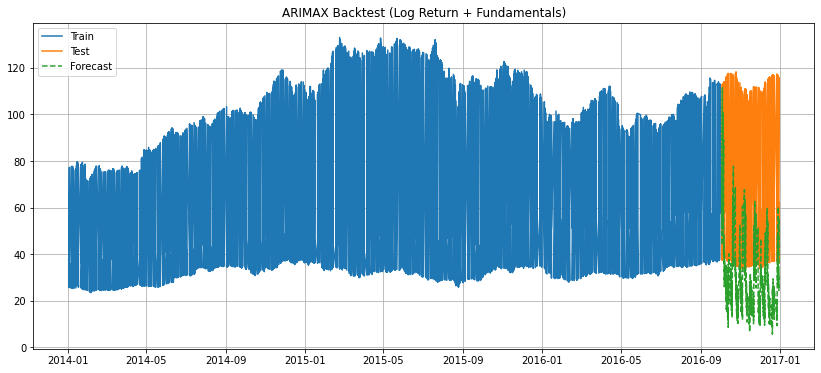

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(arima_df_train.index, arima_df_train['close'], label='Train')
plt.plot(arima_df_test.index, arima_df_test['close'], label='Test')
plt.plot(arima_df_test.index, forecast_price, '--', label='Forecast')

plt.legend()
plt.title('ARIMAX Backtest (Log Return + Fundamentals)')
plt.grid()
plt.show()

## Hyperparameter Tuning (XGBRegressor with Optuna)

In [17]:
xgb_tuning = False

In [18]:
def objective_xgb(trial): 
    # Parameters
    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 25),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 100),
        'gamma': trial.suggest_float('gamma', 0.01, 1.0),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.01, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0),
        'random_state': 2023
    }
    
    # Fit the Model
    optuna_model = XGBRegressor(**params)
    optuna_model.fit(X_train, y_train)
    
    # Make Predictions
    y_pred = optuna_model.predict(X_test)
    
    # Evaluate Predictions
    mse = mean_squared_error(y_test, y_pred)
    return mse

if(xgb_tuning):
    xgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=2023))
    xgb_study.optimize(objective_xgb, n_trials=50)

In [19]:
if(xgb_tuning):
    print('Number of finished trials: {}'.format(len(xgb_study.trials)))
    print('Best trial:')
    best_xgb = xgb_study.best_trial

    print('  Value: {}'.format(best_xgb.value))
    print('  Params: ')

    for key, value in best_xgb.params.items():
        print('    {}: {}'.format(key, value))
        
    best_params = best_xgb.params
else:
    best_params = {
        "max_depth": 20,
        "learning_rate": 0.2067525580637779,
        "n_estimators": 989,
        "min_child_weight": 84,
        "gamma": 0.311037429261164,
        "subsample": 0.6539237831027682,
        "colsample_bytree": 0.45604560131724914,
        "reg_alpha": 0.6759123826338456,
        "reg_lambda": 0.4772478981932024,
    }
    print(best_params)

{'max_depth': 20, 'learning_rate': 0.2067525580637779, 'n_estimators': 989, 'min_child_weight': 84, 'gamma': 0.311037429261164, 'subsample': 0.6539237831027682, 'colsample_bytree': 0.45604560131724914, 'reg_alpha': 0.6759123826338456, 'reg_lambda': 0.4772478981932024}


## Best Models

In [20]:
best_model = XGBRegressor(random_state=2023)
best_model.set_params(**best_params)

best_model.fit(X_train, y_train)

y_pred_train = best_model.predict(X_train)
n = X_train.shape[0]
p = X_train.shape[1]

mse = mean_squared_error(y_train, y_pred_train)
rmse = mean_squared_error(y_train, y_pred_train, squared=False)
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
adj_r2 = adjusted_r2_score(y_train, y_pred_train, n, p)

print("Metric Scores for Training")
print("MSE    :", mse)
print("RMSE   :", rmse)
print("MAE    :", mae)
print("R2     :", r2)
print("Adj R2 :", adj_r2)

y_pred = best_model.predict(X_test)
n = X_test.shape[0]
p = X_test.shape[1]

mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2_score(y_test, y_pred, n, p)

print("Metric Scores for Testing")
print("MSE    :", mse)
print("RMSE   :", rmse)
print("MAE    :", mae)
print("R2     :", r2)
print("Adj R2 :", adj_r2)

[00:19:04] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
Metric Scores for Training
MSE    : 0.04665094840676015
RMSE   : 0.21598830618058967
MAE    : 0.14102846207272324
R2     : 0.9999572767140379
Adj R2 : 0.9999510319976672
Metric Scores for Testing
MSE    : 7.769145261449108
RMSE   : 2.787318650863067
MAE    : 2.253462198680091
R2     : 0.9926363252387237
Adj R2 : 1.017978842274285


In [21]:
all_y_pred = np.concatenate((y_pred_train, y_pred))
df_actual_predicted["predicted"] = all_y_pred
df_actual_predicted_train = df_actual_predicted[df_actual_predicted["date"]<"2016-10-01"].reset_index(drop=True)
df_actual_predicted_test = df_actual_predicted[df_actual_predicted["date"]>="2016-10-01"].reset_index(drop=True)

display(df_actual_predicted)
display(df_actual_predicted_train)
display(df_actual_predicted_test)

,date,symbol,actual,predicted
0,2014-01-02,AAPL,79.018570,78.544342
1,2014-01-03,AAPL,77.282860,76.895264
2,2014-01-06,AAPL,77.704285,77.339127
3,2014-01-07,AAPL,77.148575,77.310478
4,2014-01-08,AAPL,77.637146,77.481422
...,...,...,...,...
2263,2016-12-23,MSFT,63.240002,61.325207
2264,2016-12-27,MSFT,63.279999,61.811321
2265,2016-12-28,MSFT,62.990002,61.573723
2266,2016-12-29,MSFT,62.900002,61.226734


,date,symbol,actual,predicted
0,2014-01-02,AAPL,79.018570,78.544342
1,2014-01-03,AAPL,77.282860,76.895264
2,2014-01-06,AAPL,77.704285,77.339127
3,2014-01-07,AAPL,77.148575,77.310478
4,2014-01-08,AAPL,77.637146,77.481422
...,...,...,...,...
2074,2016-09-26,MSFT,56.900002,56.846565
2075,2016-09-27,MSFT,57.950001,58.012714
2076,2016-09-28,MSFT,58.029999,57.469734
2077,2016-09-29,MSFT,57.400002,57.070534


,date,symbol,actual,predicted
0,2016-10-03,AAPL,112.519997,113.159622
1,2016-10-04,AAPL,113.000000,111.615601
2,2016-10-05,AAPL,113.050003,111.604225
3,2016-10-06,AAPL,113.889999,110.946548
4,2016-10-07,AAPL,114.059998,112.159805
...,...,...,...,...
184,2016-12-23,MSFT,63.240002,61.325207
185,2016-12-27,MSFT,63.279999,61.811321
186,2016-12-28,MSFT,62.990002,61.573723
187,2016-12-29,MSFT,62.900002,61.226734


## Closing Prices per Stock

In [22]:
# Create Subplots
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=["Apple: All Closing Prices", "Apple: Test Closing Prices", 
                    "Intel: All Closing Prices", "Intel: Test Closing Prices",
                    "Microsoft: All Closing Prices", "Microsoft: Test Closing Prices",
                   ], 
)

# Line Plot
for i in range(3):
    df_symbol_all = df_actual_predicted[df_actual_predicted["symbol"]==top_tech_symbol[i]]
    df_symbol_train = df_actual_predicted_train[df_actual_predicted_train["symbol"]==top_tech_symbol[i]]
    df_symbol_test = df_actual_predicted_test[df_actual_predicted_test["symbol"]==top_tech_symbol[i]]
    
    mse_train = round(mean_squared_error(df_symbol_train["actual"], df_symbol_train["predicted"]), 2)
    mse_test = round(mean_squared_error(df_symbol_test["actual"], df_symbol_test["predicted"]), 2)
    
    min_price = df_symbol_all["actual"].min()
    max_price = df_symbol_all["actual"].max()
    
    # All Data
    # Actual
    fig.add_trace(
        go.Scatter(
            x=df_symbol_all["date"],
            y=df_symbol_all["actual"],
            mode="lines",
            line=dict(
                width=1,
                color="#073b4c"
            ),
            name="Actual"
        ), row=i+1, col=1
    )
    
    # Train Predicted
    fig.add_trace(
        go.Scatter(
            x=df_symbol_train["date"],
            y=df_symbol_train["predicted"],
            mode="lines",
            line=dict(
                width=1.5,
                color="#ef476f"
            ),
            name="Train Predicted"
        ), row=i+1, col=1
    )
    
    # Test Predicted
    fig.add_trace(
        go.Scatter(
            x=df_symbol_test["date"],
            y=df_symbol_test["predicted"],
            mode="lines",
            line=dict(
                width=1.5,
                color="#06d6a0"
            ),
            name="Test Predicted"
        ), row=i+1, col=1
    )
    
    # Annotation
    fig.add_annotation(
        x="2016-03-01", 
        y=min_price + 0.1 * (max_price - min_price), 
        xref="x{}".format(i*2+1), yref="y{}".format(i*2+1), xanchor="left",
        text="<b>MSE Train: {}</b><br><b>MSE Test : {}</b>".format(mse_train, mse_test),
        font=dict(
            color="#073b4c",
            size=12,
        ),
        showarrow=False
    )
    
    # Test Data
    # Actual
    fig.add_trace(
        go.Scatter(
            x=df_symbol_test["date"],
            y=df_symbol_test["actual"],
            mode="lines",
            line=dict(
                width=2,
                color="#073b4c"
            ),
            name="Actual"
        ), row=i+1, col=2
    )
    
    # Predicted
    fig.add_trace(
        go.Scatter(
            x=df_symbol_test["date"],
            y=df_symbol_test["predicted"],
            mode="lines",
            line=dict(
                width=1.5,
                color="#06d6a0"
            ),
            name="Predicted"
        ), row=i+1, col=2
    )
    
    # Update Axes
    fig.update_xaxes(linecolor="Black", ticks="outside", row=i+1, col=1)
    fig.update_xaxes(linecolor="Black", ticks="outside", row=i+1, col=2)
    fig.update_yaxes(linecolor="Black", ticks="outside", row=i+1, col=1)
    fig.update_yaxes(linecolor="Black", ticks="outside", row=i+1, col=2)

# Update Layout
fig.update_layout(
    title="<b>Closing Prices per Stock</b>", title_x=0.5, font_family="Garamond", font_size=14,
    width=950, height=850,
    showlegend=False,
    plot_bgcolor="White",
    paper_bgcolor="White"
)

# Show
fig.show(renderer="iframe_connected")

## Residual Plot

In [23]:
df_actual_predicted_train["residual"] = df_actual_predicted_train["actual"] - df_actual_predicted_train["predicted"]
df_actual_predicted_test["residual"] = df_actual_predicted_test["actual"] - df_actual_predicted_test["predicted"]

# Create Subplots
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=["Apple: Train Residual", "Apple: Test Residual", 
                    "Intel: Train Residual", "Intel: Test Residual",
                    "Microsoft: Train Residual", "Microsoft: Test Residual",
                   ], 
)

# Line Plot
for i in range(3):
    df_symbol_train = df_actual_predicted_train[df_actual_predicted_train["symbol"]==top_tech_symbol[i]]
    df_symbol_test = df_actual_predicted_test[df_actual_predicted_test["symbol"]==top_tech_symbol[i]]
    
    # All Data
    # Train
    fig.add_trace(
        go.Scatter(
            x=df_symbol_train["actual"],
            y=df_symbol_train["residual"],
            mode="markers",
            marker=dict(
                color="#ef476f",
                size=6
            ),
            name="Residual"
        ), row=i+1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=[df_symbol_train["actual"].min(), df_symbol_train["actual"].max()],
            y=[0.0, 0.0],
            mode="lines",
            line=dict(
                color="#073b4c",
                width=3
            ),
            name="Actual"
        ), row=i+1, col=1
    )
    
    # Test
    fig.add_trace(
        go.Scatter(
            x=df_symbol_test["actual"],
            y=df_symbol_test["residual"],
            mode="markers",
            marker=dict(
                color="#06d6a0",
                size=6
            ),
            name="Residual"
        ), row=i+1, col=2
    )
    fig.add_trace(
        go.Scatter(
            x=[df_symbol_test["actual"].min(), df_symbol_test["actual"].max()],
            y=[0.0, 0.0],
            mode="lines",
            line=dict(
                color="#073b4c",
                width=3
            ),
            name="Actual"
        ), row=i+1, col=2
    )
    
    # Update Axes
    fig.update_xaxes(linecolor="Black", ticks="outside", row=i+1, col=1)
    fig.update_xaxes(linecolor="Black", ticks="outside", row=i+1, col=2)
    fig.update_yaxes(linecolor="Black", ticks="outside", row=i+1, col=1)
    fig.update_yaxes(linecolor="Black", ticks="outside", row=i+1, col=2)

# Update Layout
fig.update_layout(
    title="<b>Residual Plot</b>", title_x=0.5, font_family="Garamond", font_size=14,
    width=950, height=850,
    showlegend=False,
    plot_bgcolor="White",
    paper_bgcolor="White"
)

# Show
fig.show(renderer="iframe_connected")

## Feature Importance

In [24]:
# Create DataFrame
df_importance = pd.DataFrame()
df_importance["Features"] = X_train.columns
df_importance["Importance"] = best_model.feature_importances_
df_importance = df_importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)[:20]
df_importance = df_importance.sort_values(by="Importance", ascending=True).reset_index(drop=True)

# Create Figure
fig = go.Figure()

# Bar Plot
fig.add_trace(
    go.Bar(
        x=df_importance["Importance"],
        y=df_importance["Features"],
        orientation="h",
        name="Importance",
        marker_color="#118ab2",
        width=0.8
    )
)

# Annotations
for i in range(20):
    fig.add_annotation(
        x=df_importance["Importance"][i] + 0.003, y=df_importance["Features"][i], 
        xref="x1", yref="y1", xanchor="left",
        text="<b>{}</b>".format(df_importance["Features"][i]),
        font=dict(
            color="#118ab2",
            size=12,
        ),
        showarrow=False
    )

# Update Axes
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)

# Update Layout
fig.update_layout(
    title="<b>Top 20 Feature Importance</b>", title_x=0.5,
    font_family="Garamond", font_size=14,
    width=950, height=900,
    plot_bgcolor="White",
    showlegend=False
)

# Show
fig.show(renderer="iframe_connected")